# 02 · Preprocessing: domain, data and derivatives

Before the search starts, EPDE needs the grid, the data on it and the derivatives
of every variable. Every term of every candidate equation is computed from these
arrays, so their quality bounds what any search can find.

* The **domain** is the grid: one array per axis, time first. For a partial
  differential equation the arrays come from a mesh grid with matrix indexing.
  Points near the edges are excluded from fitting, because derivatives are least
  accurate there.
* The **trajectory** attaches the data to the domain. Derivatives are computed
  at this moment by the chosen preprocessor.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


## Domain and trajectory for a one-dimensional partial differential equation

In [2]:
from epde import EpdeSearch
problem = datasets.load('burgers')
search = EpdeSearch(config={'domain': {'boundary_width': [10, 25]},
                            'preprocessing': {'default_preprocessor_type': 'FD', 'max_deriv_order': [1, 2]},
                            'runtime': {'memory_for_cache': 2}})
_, domain = search.createDomain(list(problem.grids), ID=0)
_, trajectory = search.createTrajectory(problem.data, domain, cache_id=0)
print('grid shape:', problem.shape)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000252047C7080>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000252047C7080>
Set domain <epde.structure.domain.Domain object at 0x00000252047C7020> with inner shape of [ 81 206]
grid shape: (101, 256)


## Preprocessors

EPDE has four ways to compute derivatives:

| preprocessor | method |
|---|---|
| finite differences | central differences on the grid |
| polynomial fits | derivatives of local Chebyshev polynomial fits; smooths noise |
| spectral | Fourier differentiation with a cut-off of high frequencies |
| neural network | derivatives of a network fitted to the data |

Noise is where they differ most. Below is the second derivative of the Van der Pol
signal with 2 % noise, computed with finite differences and with polynomial fits.

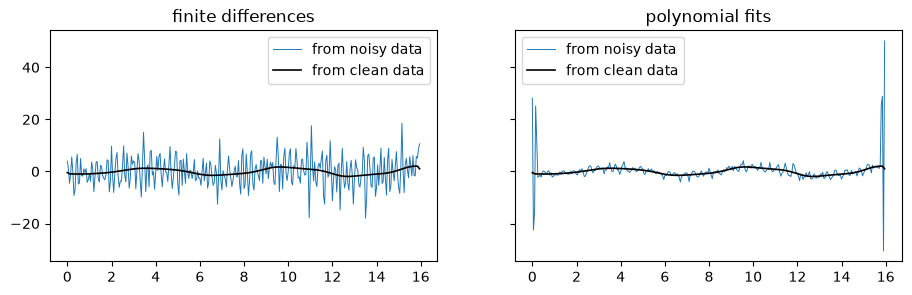

In [3]:
from epde_bench.preprocessing import prepare_data
p = datasets.load('vdp'); t = p.grids[0]
clean = p.data; noisy = p.noisy(2, seed=0)
_, clean_derivs = prepare_data(p, clean, resolve_for_problem(load_config('vdp'), p))
d2_true = clean_derivs['u'][:, 1]
fig, ax = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for a, (variant, label) in zip(ax, [('default', 'finite differences'), ('poly', 'polynomial fits')]):
    cfg = resolve_for_problem(load_config('vdp', variant), p)
    if variant == 'poly':      # keep the demonstration deterministic and single-process
        cfg['preprocessing'].setdefault('preprocessor_kwargs', {})['mp_poolsize'] = 1
    _, derivatives = prepare_data(p, noisy, cfg)
    a.plot(t, derivatives['u'][:, 1], lw=.7, label='from noisy data')
    a.plot(t, d2_true, 'k', lw=1.2, label='from clean data'); a.set_title(label); a.legend()
plt.show()

## Supplied derivatives

When the grid is too coarse for numerical differentiation, derivatives can be
passed with the data. The turbulence slice ships spatial gradients from the
direct numerical simulation; they are used as given, column by column, in the
order of the axes.

In [4]:
p = datasets.load('jhtdb_plane')
print('derivative orders per axis (t, y, x):', p.deriv_orders)
print('stack shapes:', [d.shape for d in p.derivs])

derivative orders per axis (t, y, x): [1, 1, 1]
stack shapes: [(92160, 3), (92160, 3)]


Artificial noise is not added to such records: noisy fields with noise-free
gradients would describe two different signals.

## Is the law still visible in the data?

The signal check evaluates the terms of the known law on the preprocessed data
and fits their coefficients by least squares. It reports the share of the target
explained by the true structure and, for each term, how much of it is lost when
the term is removed. A term that explains almost nothing cannot be identified by
any method under this preprocessing. The Allen–Cahn equation is an example: its
diffusion coefficient is $10^{-4}$.

In [5]:
p, report = check('ac', noise_levels=[0, 1, 5])
print_check(p, report)

ac: Allen-Cahn equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (51, 128); variables: u
  t: [0, 1], 51 points
  x: [-1, 0.9844], 128 points
  truth:
    0.0001 * d^2u/dx1^2{power: 1.0} + -5.0 * u{power: 3.0} + 5.0 * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = 1e-4 u_xx + 5u - 5u^3. The diffusion term is tiny, which makes it hard to separate from noise.

=== noise 0 % ===
R^2 of the true structure: 0.999962   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  d^2u/dx1^2{'power': 1.0}                                       0.0001   0.00013592            2.034e-04
  u{'power': 3.0}                                                    -5      -4.9911            4.619e-01
  u{'power': 1.0}                                                     5       4.9946            6.916e-01

=== noise 1 % ===
R^2 of the true structure: 0.949060   (du/dx0{power: 1.0})
  term               

In [6]:
p, report = check('ac', noise_levels=[0, 1, 5], variant='poly',
                  overrides={'search': {'preprocessing': {'preprocessor_kwargs': {'mp_poolsize': 1}}}})
print_check(p, report)

ac: Allen-Cahn equation
  class: PDE, 1 space dimension, source: synthetic
  axes: t, x; data shape: (51, 128); variables: u
  t: [0, 1], 51 points
  x: [-1, 0.9844], 128 points
  truth:
    0.0001 * d^2u/dx1^2{power: 1.0} + -5.0 * u{power: 3.0} + 5.0 * u{power: 1.0} = du/dx0{power: 1.0}
  notes: u_t = 1e-4 u_xx + 5u - 5u^3. The diffusion term is tiny, which makes it hard to separate from noise.

=== noise 0 % ===
R^2 of the true structure: 0.999925   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  d^2u/dx1^2{'power': 1.0}                                       0.0001   0.00011915            1.623e-04
  u{'power': 3.0}                                                    -5      -4.9948            4.636e-01
  u{'power': 1.0}                                                     5       4.9969            6.946e-01

=== noise 1 % ===
R^2 of the true structure: 0.986411   (du/dx0{power: 1.0})
  term               